In [1]:
!pip install transformers datasets accelerate scikit-learn matplotlib numpy pandas torch torchvision torchaudio --quiet

                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1598
          ethnicity       0.98      0.97      0.97      1592
             gender       0.91      0.83      0.87      1595
  not_cyberbullying       0.58      0.52      0.55      1589
other_cyberbullying       0.57      0.69      0.62      1565
           religion       0.95      0.95      0.95      1600

           accuracy                           0.82      9539
          macro avg       0.83      0.82      0.82      9539
       weighted avg       0.83      0.82      0.82      9539

baseline accuracy (tf-idf + logreg): 0.8218890869063843


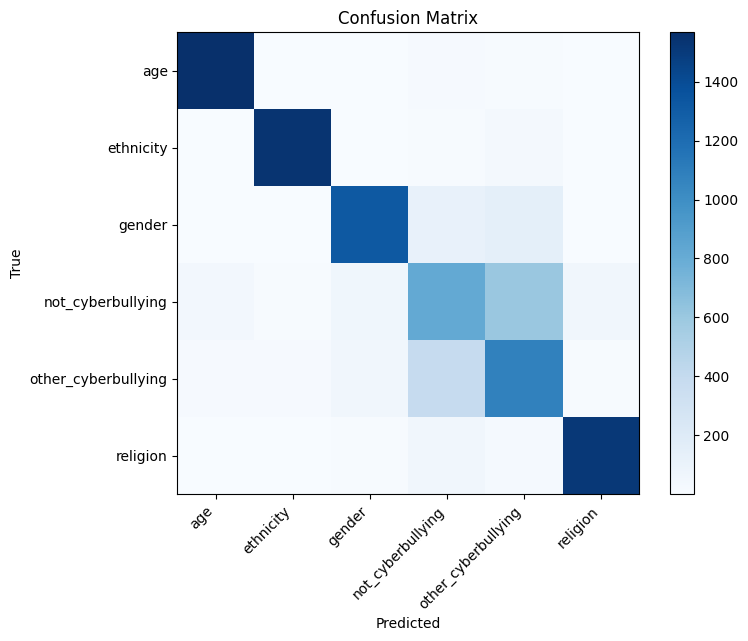

In [3]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("cyberbullying_tweets.csv")    # load dataset

def clean_text(text):    # clean function
    text = re.sub(r"http\S+", "", text)    # remove urls
    text = re.sub(r"@\w+", "", text)    # remove mentions
    text = text.lower()    # lowercase text
    return text

df['clean_text'] = df['tweet_text'].apply(clean_text)    # cleaning

X = df['clean_text']    # input text
y = df['cyberbullying_type']    # target labels

X_train, X_test, y_train, y_test = train_test_split(    # split data
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))    # vectorizer
X_train_vec = tfidf.fit_transform(X_train)    # fit + transform train
X_test_vec = tfidf.transform(X_test)    # transform test

clf = LogisticRegression(max_iter=2000)    # define model
clf.fit(X_train_vec, y_train)    # train model

y_pred = clf.predict(X_test_vec)    # predict labels
print(classification_report(y_test, y_pred))    # print metric
baseline_accuracy = accuracy_score(y_test, y_pred)    # baseline accuracy
print("baseline accuracy (tf-idf + logreg):", baseline_accuracy)

from sklearn.metrics import confusion_matrix    # import confusion matrix
import matplotlib.pyplot as plt    # for plots
import numpy as np    # for arrays

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)    # build matrix

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(len(clf.classes_)), clf.classes_, rotation=45, ha='right')
plt.yticks(np.arange(len(clf.classes_)), clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [6]:
import torch
from sklearn.metrics import classification_report, accuracy_score # metrics
from sklearn.preprocessing import LabelEncoder  # label encoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# prepare columns
TEXT_COL = "tweet_text" # text column
LABEL_COL = "cyberbullying_type"  # label column

# prepare text + labels
texts = df[TEXT_COL].astype(str).apply(clean_text).tolist() # clean text
labels = df[LABEL_COL].astype(str).tolist() # get labels

# train-test split (same as baseline for fair comparison)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# encode labels
label_encoder = LabelEncoder()    # label encoder
y_train_ids = label_encoder.fit_transform(y_train_t)    # encode train
y_test_ids = label_encoder.transform(y_test_t)    # encode test

num_labels = len(label_encoder.classes_)    # number of classes
print("classes:", label_encoder.classes_)    # print classes

# load tokenizer + model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)    # load tokenizer
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# dataset class for trainer
class CyberDataset(torch.utils.data.Dataset):    # dataset
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)    # length

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}    # inputs
        item["labels"] = torch.tensor(self.labels[idx])    # label
        return item

# build datasets
train_dataset = CyberDataset(X_train_t, y_train_ids, tokenizer)
test_dataset = CyberDataset(X_test_t, y_test_ids, tokenizer)

# training args (minimal -> compatible)
training_args = TrainingArguments(
    output_dir="./bert_results",    # output dir
    num_train_epochs=2,    # epochs
    per_device_train_batch_size=16,    # train batch size
    per_device_eval_batch_size=32,    # eval batch size
    learning_rate=2e-5,    # learning rate
    weight_decay=0.     # regularization
)

# metric function
def compute_metrics(eval_pred):    # compute accuracy
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,  # Передаём токенизатор через processing_class
    compute_metrics=compute_metrics
)

print("training distilbert with trainer...")
trainer.train()

print("evaluating distilbert with trainer...")
preds_output = trainer.predict(test_dataset)    # predictions
y_pred_ids = preds_output.predictions.argmax(axis=-1)
y_pred_labels = label_encoder.inverse_transform(y_pred_ids)

classes: ['age' 'ethnicity' 'gender' 'not_cyberbullying' 'other_cyberbullying'
 'religion']


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


training distilbert with trainer...


Step,Training Loss
500,0.676298
1000,0.426978
1500,0.386400
2000,0.359606
2500,0.350913
3000,0.303128
3500,0.311535
4000,0.290113
4500,0.295752


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

evaluating distilbert with trainer...


                     precision    recall  f1-score   support

                age       0.99      0.98      0.98      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.90      0.89      0.90      1595
  not_cyberbullying       0.72      0.57      0.64      1589
other_cyberbullying       0.66      0.81      0.72      1565
           religion       0.96      0.96      0.96      1600

           accuracy                           0.86      9539
          macro avg       0.87      0.86      0.86      9539
       weighted avg       0.87      0.86      0.86      9539

transformer accuracy: 0.8649753642939512
baseline vs transformer accuracy:
baseline: 0.8218890869063843
transformer: 0.8649753642939512


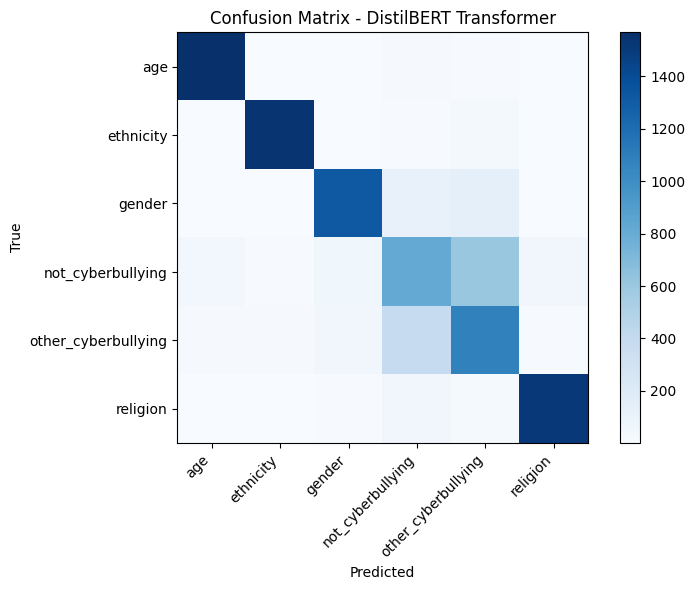

In [7]:
print(classification_report(y_test_t, y_pred_labels)) # report

transformer_accuracy = accuracy_score(y_test_t, y_pred_labels)  # accuracy
print("transformer accuracy:", transformer_accuracy)

# compare with baseline
try:
    print("baseline vs transformer accuracy:")
    print("baseline:", baseline_accuracy)
    print("transformer:", transformer_accuracy)
except NameError:
    print("error")

labels_order = label_encoder.classes_          # class names

cm_trans = confusion_matrix(y_test, y_pred, labels=clf.classes_)   # build matrix

plt.figure(figsize=(8,6))
plt.imshow(cm_trans, cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(len(labels_order)), labels_order, rotation=45, ha='right')
plt.yticks(np.arange(len(labels_order)), labels_order)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DistilBERT Transformer")
plt.tight_layout()
plt.show()